# Chapter 11: Point Pattern Analysis

*Part II — Geographic Data Science*

## Learning Objectives

By the end of this chapter you will be able to:

- Visualize a point pattern with scatter plots, hexbin density, and kernel density estimation (KDE)
- Summarize a point pattern's shape and spread with centrography: mean center, standard distance, and the standard deviational ellipse
- Test whether a point pattern is more clustered than pure chance would produce, using a quadrat test
- Tell repeated satellite detections from independent events, and test against randomness inside the real study area rather than a bounding box

## From Polygons to Points

Every chapter since Chapter 6 has worked with data that already lives inside a polygon — a municipality, a grid cell, a raster pixel. But plenty of real geographic data starts life as neither: a crime report, a disease case, a tree in a forest survey, a photograph's GPS tag. Each is a bare `(x, y)` location, with no polygon attached at all until an analyst decides to draw one.

Point pattern analysis studies that raw form directly, before any aggregation choice gets made. It asks two questions in particular: what does this scatter of points look like, summarized a few different ways — and is it more clustered (or more dispersed) than pure randomness would produce? Both questions have to be answered before choosing *how* to aggregate the points into the polygons the rest of Part II already knows how to analyze.

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import gaussian_kde
from pointpats import centrography, QStatistic

np.random.seed(1)

## A Synthetic Point Pattern

This chapter builds a point pattern with a *known* structure — two clusters — rather than starting from real coordinates, the same reasoning Chapters 12 through 14 continue with their own synthetic grids. Knowing the ground truth is what lets the rest of the chapter confirm that each technique actually detects the structure that's really there, instead of taking a plausible-looking result on faith.

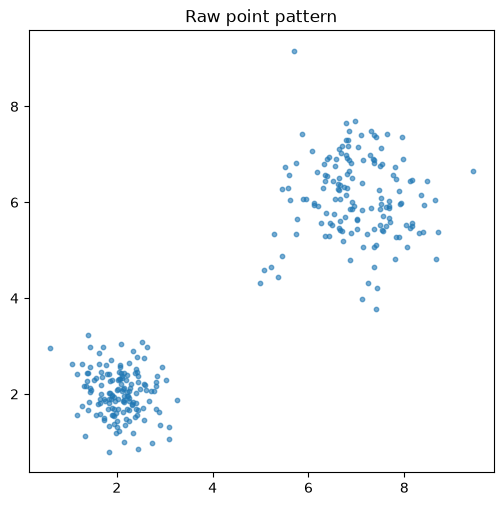

In [2]:
# Two clusters plus general scatter, in the same coordinate space
cluster_a = np.random.normal(loc=[2, 2], scale=0.5, size=(150, 2))
cluster_b = np.random.normal(loc=[7, 6], scale=0.8, size=(150, 2))
points = np.vstack([cluster_a, cluster_b])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(points[:, 0], points[:, 1], s=10, alpha=0.6)
ax.set_title("Raw point pattern")
ax.set_aspect("equal")

## Visualizing Density: Hexbin and KDE

A plain scatter plot already shows two clusters here — but with a few thousand points instead of three hundred, individual markers overlap into an unreadable smear. Two techniques summarize density instead of plotting every point: `hexbin`, which counts points falling into hexagonal cells and colors by that count, and kernel density estimation (KDE), which smooths those counts into a continuous surface.

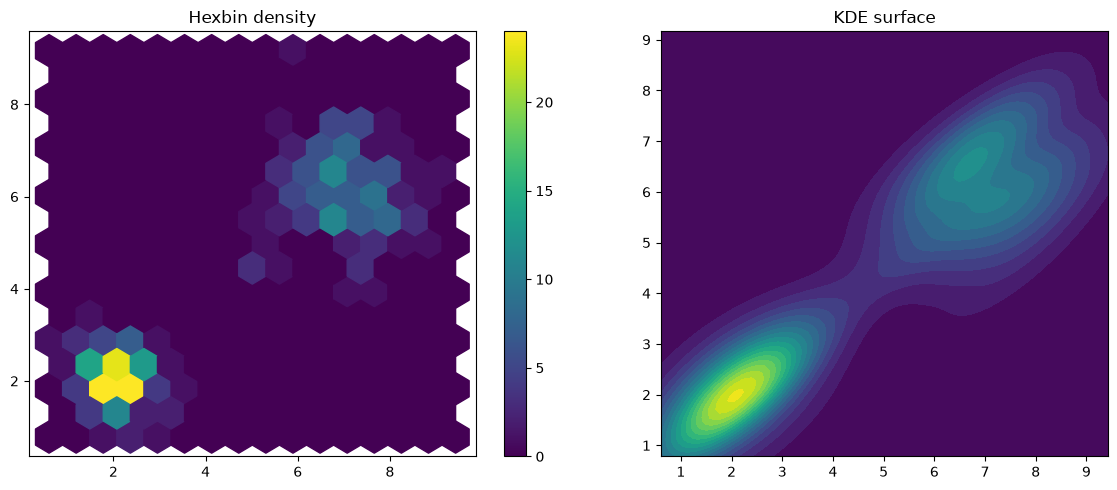

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

hb = axes[0].hexbin(points[:, 0], points[:, 1], gridsize=15, cmap="viridis")
axes[0].set_title("Hexbin density")
axes[0].set_aspect("equal")
plt.colorbar(hb, ax=axes[0])

kde = gaussian_kde(points.T)
xgrid, ygrid = np.mgrid[points[:, 0].min():points[:, 0].max():100j,
                        points[:, 1].min():points[:, 1].max():100j]
density = kde(np.vstack([xgrid.ravel(), ygrid.ravel()])).reshape(xgrid.shape)
axes[1].contourf(xgrid, ygrid, density, levels=20, cmap="viridis")
axes[1].set_title("KDE surface")
axes[1].set_aspect("equal")

plt.tight_layout()

`hexbin` is a direct count — easy to interpret, but its apparent smoothness depends entirely on `gridsize`, the same way a choropleth's story depends on its classification scheme (Chapter 15). KDE trades that dependency for a different one — a bandwidth parameter (`gaussian_kde`'s default, here) controlling how far each point's influence spreads — in exchange for a genuinely continuous surface rather than a grid of counts.

## Centrography: Summarizing a Pattern with a Few Numbers

Before testing whether a pattern is random, it helps to describe it: where is its center, how spread out is it, and does it stretch in one direction more than another? `pointpats.centrography` answers exactly these three questions.

Mean center: (4.53, 4.05)
Standard distance: 3.34
Ellipse semi-axes: 4.64, 1.00  (theta=0.69 rad)


Text(0.5, 1.0, 'Centrography summary')

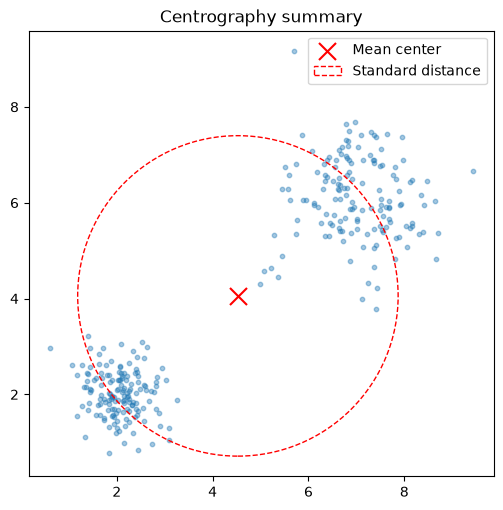

In [4]:
mean_center = centrography.mean_center(points)
std_dist = centrography.std_distance(points)
semi_major, semi_minor, theta = centrography.ellipse(points)

print(f"Mean center: ({mean_center[0]:.2f}, {mean_center[1]:.2f})")
print(f"Standard distance: {std_dist:.2f}")
print(f"Ellipse semi-axes: {semi_major:.2f}, {semi_minor:.2f}  (theta={theta:.2f} rad)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(points[:, 0], points[:, 1], s=10, alpha=0.4)
ax.scatter(*mean_center, color="red", marker="x", s=150, label="Mean center")
circle = plt.Circle(mean_center, std_dist, fill=False, color="red", linestyle="--", label="Standard distance")
ax.add_patch(circle)
ax.set_aspect("equal")
ax.legend()
ax.set_title("Centrography summary")

The mean center lands between the two synthetic clusters — a reminder that a single summary point can be a poor description of a pattern that's actually bimodal. The standard-distance circle captures that same limitation visually: it has to be large enough to cover a fairly spread-out pattern, so a lot of genuinely empty space between the two clusters ends up inside it. Centrography is a fast, honest first look — not a substitute for actually visualizing the pattern first, which is exactly why it comes after the hexbin and KDE plots above, not before them.

## Is This Pattern Random? The Quadrat Test

Everything so far described the pattern that exists. This section asks a sharper question: if points had landed by pure chance — complete spatial randomness (CSR) — how likely is a pattern this clustered to occur? `QStatistic` answers this by dividing the study area into a grid of quadrats, counting points per quadrat, and comparing that count's variance to what CSR would predict via a chi-squared test.

To make the comparison meaningful, this section builds a second, genuinely random pattern in the same bounding box as the clustered one above — the fair test isn't clustered-versus-nothing, but clustered-versus-CSR in the identical study area.

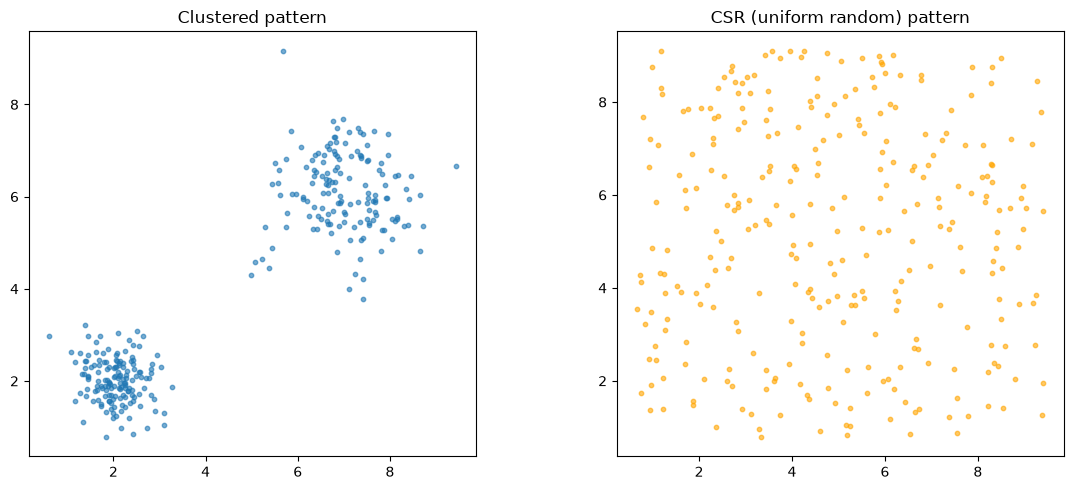

In [5]:
random_points = np.random.uniform(
    low=points.min(axis=0), high=points.max(axis=0), size=(300, 2)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(points[:, 0], points[:, 1], s=10, alpha=0.6)
axes[0].set_title("Clustered pattern")
axes[0].set_aspect("equal")
axes[1].scatter(random_points[:, 0], random_points[:, 1], s=10, alpha=0.6, color="orange")
axes[1].set_title("CSR (uniform random) pattern")
axes[1].set_aspect("equal")
plt.tight_layout()

In [6]:
for name, pts in [("Clustered", points), ("CSR", random_points)]:
    q = QStatistic(pts, shape="rectangle", nx=10, ny=10)
    print(f"{name:10s}  chi2 = {q.chi2:8.2f}   p-value = {q.chi2_pvalue:.4f}")

Clustered   chi2 =  2016.00   p-value = 0.0000
CSR         chi2 =    82.67   p-value = 0.8817


The clustered pattern's chi-squared statistic comes out in the thousands with a p-value indistinguishable from zero — CSR is rejected outright. The genuinely random pattern's p-value, by contrast, sits comfortably above any conventional significance threshold: exactly the outcome that confirms the test isn't simply flagging every pattern as clustered by default. The same quadrat grid used for this test, notice, is itself doing something close to the areal aggregation Chapter 12 assumes as its starting point — counting points per cell is one honest way to turn this chapter's raw locations into next chapter's per-unit variable.

## A Real Pattern: Fire Hotspots in Maranhão

<div class="admonition note">
<p class="admonition-title">A teaching example</p>
<p>Two days of fire detections are enough to exercise every technique in this chapter, and far too little to say anything general about fire in Maranhão. The results below illustrate the methods — including two traps that real point data set for them — not the geography of burning.</p>
</div>

The synthetic pattern above has a known structure by construction. A real point pattern offers no such guarantee — but it lets the same tools be checked against a dataset where the underlying process (fire) is genuinely uncertain in space, unlike the two hand-placed Gaussian clusters above.

The dataset below is a two-day extract (September 5–6, 2026) from INPE's BDQueimadas program, filtered to Maranhão: 1,260 satellite-detected fire hotspots, each a bare `(latitude, longitude)` pair with no polygon attached — precisely the raw form Section 1 above described. Coordinates are reprojected to SIRGAS 2000 / UTM 23S (EPSG:31983), the same projected CRS Chapter 6 used for Maranhão, so that `std_distance` and the quadrat grid operate on meters rather than degrees.

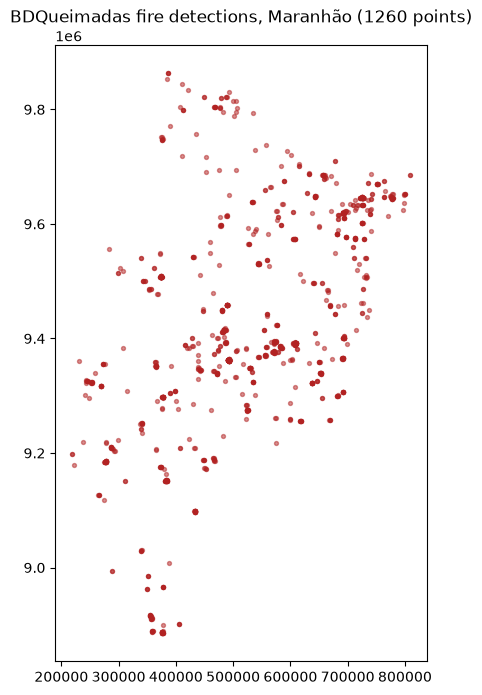

In [7]:
import pandas as pd
import geopandas as gpd

fire_df = pd.read_csv("bdqueimadas_ma.csv")
fire_gdf = gpd.GeoDataFrame(
    fire_df,
    geometry=gpd.points_from_xy(fire_df.Longitude, fire_df.Latitude),
    crs="EPSG:4326",
).to_crs("EPSG:31983")

fire_points = np.column_stack([fire_gdf.geometry.x, fire_gdf.geometry.y])

fig, ax = plt.subplots(figsize=(6, 8))
ax.scatter(fire_points[:, 0], fire_points[:, 1], s=8, alpha=0.5, color="firebrick")
ax.set_title(f"BDQueimadas fire detections, Maranhão ({len(fire_points)} points)")
ax.set_aspect("equal")


### Trap 1: Detections Are Not Fires

A point pattern test assumes each point is a separate event. BDQueimadas does not promise that: the file above holds the detections of *every* satellite INPE processes, and several of them see the same fire, pass after pass, on the same day. Counting passes and near-duplicates makes this concrete:

In [8]:
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

detected_at = pd.to_datetime(fire_df["DataHora"])
print(f"{len(fire_points)} detections, {detected_at.nunique()} distinct satellite-pass times")

# Merge detections less than 1.5 km apart on the same day into one fire event
day = detected_at.dt.date.to_numpy()
pairs = np.array([(a, b) for a, b in cKDTree(fire_points).query_pairs(1500) if day[a] == day[b]])
links = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])), shape=(len(fire_points),) * 2)
n_events, event_id = connected_components(links, directed=False)
event_points = pd.DataFrame(fire_points, columns=["x", "y"]).groupby(event_id).mean().to_numpy()
print(f"{n_events} fire events after merging same-day detections within 1.5 km")

fire_points = event_points  # from here on, the chapter analyses events, not detections

1260 detections, 119 distinct satellite-pass times
389 fire events after merging same-day detections within 1.5 km


About two thirds of the detections are repeats of a nearby detection on the same day. Left in, they would make any clustering test partly measure how often satellites revisit the same fire. The 1.5 km merge distance is a simple, adjustable choice, not a standard — a finer analysis would use INPE's single *reference satellite* series, which is built for exactly this purpose. Everything below uses the merged events.

Unlike the synthetic pattern's two round, evenly filled clusters, the hotspots trail along a diagonal band and leave the whole northern half of the state — the coast and the Amazônia biome near it — almost empty. Nearly all of these two days' detections fall in the Cerrado municipalities of the interior (Barra do Corda, Alto Parnaíba, Santa Quitéria do Maranhão among the most frequent), consistent with dry-season agricultural burning rather than a mangrove or coastal process — a reminder that "clustered" can mean an elongated corridor following a land-use boundary, not just a blob.

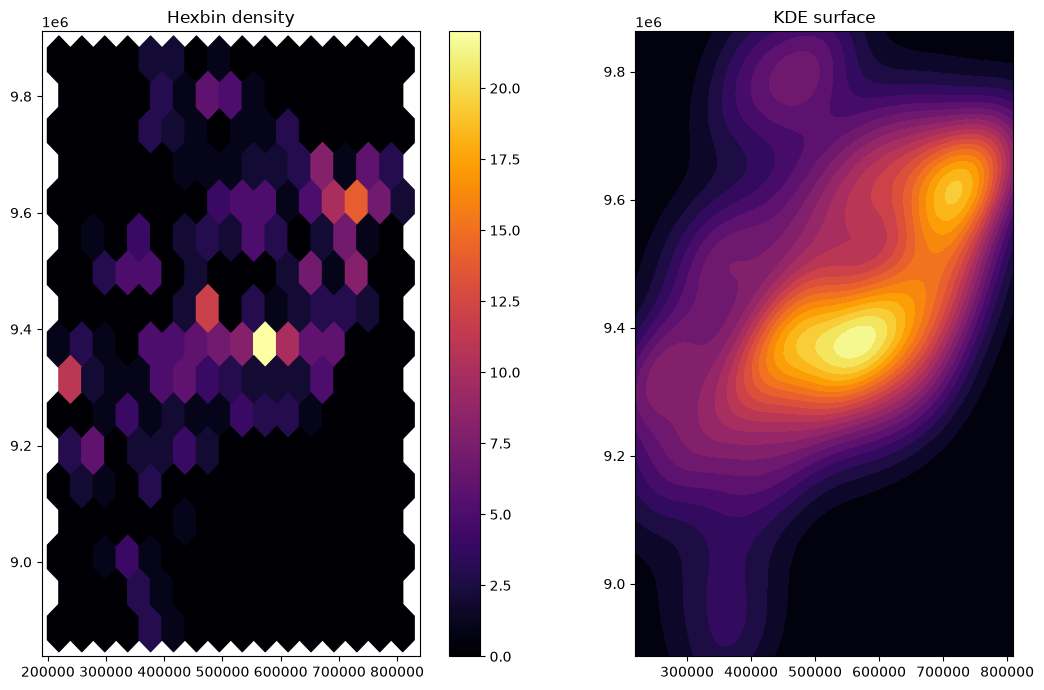

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

hb = axes[0].hexbin(fire_points[:, 0], fire_points[:, 1], gridsize=15, cmap="inferno")
axes[0].set_title("Hexbin density")
axes[0].set_aspect("equal")
plt.colorbar(hb, ax=axes[0])

kde_fire = gaussian_kde(fire_points.T)
xg, yg = np.mgrid[
    fire_points[:, 0].min():fire_points[:, 0].max():100j,
    fire_points[:, 1].min():fire_points[:, 1].max():100j,
]
density_fire = kde_fire(np.vstack([xg.ravel(), yg.ravel()])).reshape(xg.shape)
axes[1].contourf(xg, yg, density_fire, levels=20, cmap="inferno")
axes[1].set_title("KDE surface")
axes[1].set_aspect("equal")

plt.tight_layout()


Both surfaces pick out two or three denser pockets along the same interior corridor rather than one dominant peak — a genuinely multi-modal real pattern, messier than the synthetic pair of clusters but detected by the identical code.

Mean center (UTM 23S, m): (526855, 9451365)
Standard distance: 242.9 km
Ellipse semi-axes: 298.4 km, 171.9 km (theta=1.07 rad)


Text(0.5, 1.0, 'Centrography: Maranhão fire hotspots')

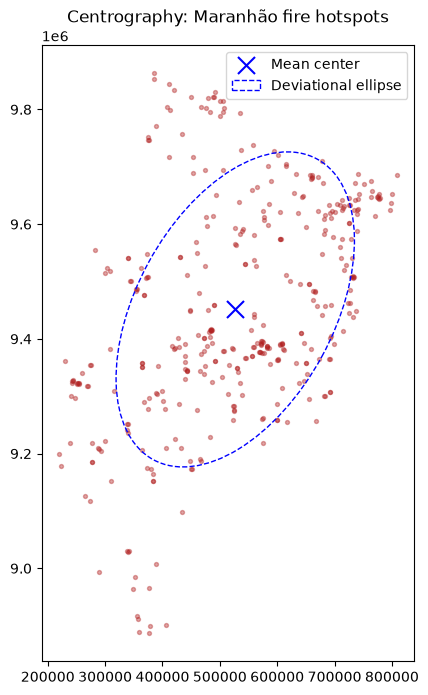

In [10]:
mean_center_fire = centrography.mean_center(fire_points)
std_dist_fire = centrography.std_distance(fire_points)
semi_major_fire, semi_minor_fire, theta_fire = centrography.ellipse(fire_points)

print(f"Mean center (UTM 23S, m): ({mean_center_fire[0]:.0f}, {mean_center_fire[1]:.0f})")
print(f"Standard distance: {std_dist_fire / 1000:.1f} km")
print(f"Ellipse semi-axes: {semi_major_fire / 1000:.1f} km, {semi_minor_fire / 1000:.1f} km (theta={theta_fire:.2f} rad)")

fig, ax = plt.subplots(figsize=(6, 8))
ax.scatter(fire_points[:, 0], fire_points[:, 1], s=8, alpha=0.4, color="firebrick")
ax.scatter(*mean_center_fire, color="blue", marker="x", s=150, label="Mean center")
ellipse_patch = Ellipse(
    mean_center_fire, 2 * semi_major_fire, 2 * semi_minor_fire,
    angle=np.degrees(theta_fire), fill=False, color="blue", linestyle="--", label="Deviational ellipse",
)
ax.add_patch(ellipse_patch)
ax.set_aspect("equal")
ax.legend()
ax.set_title("Centrography: Maranhão fire hotspots")


The ellipse's long axis runs roughly southwest–northeast, tracing the same interior corridor visible in the raw scatter — exactly the elongated, directional structure a circular standard-distance summary alone would flatten out. This is the practical case for computing the full ellipse (`centrography.ellipse`) rather than stopping at `std_distance`: a state-sized standard-distance circle here would cover the empty coast along with the actual hotspot corridor.

In [11]:
rng = np.random.default_rng(1)
random_fire = rng.uniform(
    low=fire_points.min(axis=0), high=fire_points.max(axis=0), size=(len(fire_points), 2)
)

for name, pts in [("Fire hotspots", fire_points), ("CSR", random_fire)]:
    q = QStatistic(pts, shape="rectangle", nx=10, ny=10)
    print(f"{name:15s}  chi2 = {q.chi2:10.2f}   p-value = {q.chi2_pvalue:.4f}")


Fire hotspots    chi2 =     687.86   p-value = 0.0000
CSR              chi2 =      91.46   p-value = 0.6922


The fire events reject CSR decisively, while a uniform-random pattern in the same box does not. But that comparison hides a second trap.

### Trap 2: The Wrong Study Area

The random points above were drawn in the *bounding rectangle* of the fires, and Maranhão is not a rectangle: much of that box is ocean or a neighboring state, where no fire can ever be recorded. Against a null model that puts points in places where points are impossible, almost any real pattern looks "clustered". The fix is to draw the random points inside the state itself, and to use a test built for that — Ripley's L function, compared against many random patterns simulated inside the same polygon:

In [12]:
from pointpats import QStatistic, l_test

url = (
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/"
    "malhas_municipais/municipio_2025/UFs/MA/MA_Municipios_2025.zip"
)
state = gpd.read_file(url).to_crs("EPSG:31983").union_all()
state = max(state.geoms, key=lambda p: p.area) if state.geom_type == "MultiPolygon" else state

# The bounding-box trap, made visible: random points drawn INSIDE Maranhão also "fail" the rectangle test
rng = np.random.default_rng(2)
minx, miny, maxx, maxy = state.bounds
candidates = rng.uniform([minx, miny], [maxx, maxy], size=(20 * len(fire_points), 2))
inside = gpd.GeoSeries(gpd.points_from_xy(candidates[:, 0], candidates[:, 1]), crs="EPSG:31983").within(state).to_numpy()
csr_in_state = candidates[inside][: len(fire_points)]
q = QStatistic(csr_in_state, shape="rectangle", nx=10, ny=10)
print(f"Random points inside Maranhão, rectangle quadrat test: p-value = {q.chi2_pvalue:.2g}")

# Ripley's L inside the state polygon, 99 random patterns simulated in the same window
distances = np.array([5, 10, 20, 50, 100, 150]) * 1000
events_in_state = fire_points[
    gpd.GeoSeries(gpd.points_from_xy(fire_points[:, 0], fire_points[:, 1]), crs="EPSG:31983").within(state).to_numpy()
]
result = l_test(events_in_state, support=distances, hull=state, n_simulations=99)
for d, observed, p in zip(distances / 1000, result.statistic / 1000, result.pvalue):
    print(f"d = {d:5.0f} km   L(d) = {observed:6.1f} km   p = {p:.2f}")

Random points inside Maranhão, rectangle quadrat test: p-value = 5.8e-38


d =     5 km   L(d) =   20.5 km   p = 0.01
d =    10 km   L(d) =   26.1 km   p = 0.01
d =    20 km   L(d) =   42.5 km   p = 0.01
d =    50 km   L(d) =   81.7 km   p = 0.01
d =   100 km   L(d) =  138.7 km   p = 0.01
d =   150 km   L(d) =  192.9 km   p = 0.04


The first line is the trap in one number: points that *are* random inside Maranhão still fail the rectangle test by a wide margin, simply because the state is not a rectangle. The L function avoids that by simulating inside the real outline. For a random pattern, L(d) stays close to d; here L(d) is well above d at every distance from 5 to 150 km, and none of the 99 simulated patterns reaches it at short distances. So, measured inside the right window, fire events are still clustered.

What this does *not* say is why. Most of the events fall in the Cerrado part of the state, which has more fire to begin with. "More fires where there is more to burn" (a varying intensity, a *first-order* effect) and "a fire makes nearby fires more likely" (interaction, a *second-order* effect) both produce clustering, and the tests in this chapter cannot tell them apart. Separating them needs an intensity model — for example, randomness conditioned on biome or land cover — which is a natural next step, not something two days of data can settle.

## A Bridge to Chapter 12

Chapter 12 picks up exactly where the quadrat test's grid left off, but from the other direction: instead of asking whether points are randomly scattered across cells, it asks whether a variable *already aggregated* into areal units — one number per municipality or per grid cell — clusters in space more than chance would predict. Moran's I is the areal-data cousin of the quadrat test above; the counts this chapter's grid produced are exactly the kind of per-cell variable that test is built to examine.

## Exercises

1. **A single cluster.** Rebuild `points` using only `cluster_a` (drop `cluster_b` entirely) and rerun the KDE plot. Does the KDE surface still look meaningfully different from a CSR pattern covering the same bounding box?
2. **Quadrat resolution.** Rerun `QStatistic` on the clustered pattern with `nx=5, ny=5` instead of `nx=10, ny=10`. Does the test still reject CSR as strongly? What does that suggest about how sensitive the quadrat test is to the resolution chosen, compared to KDE's sensitivity to bandwidth?
3. **Centrography on each cluster separately.** Compute `centrography.mean_center` and `std_distance` for `cluster_a` and `cluster_b` individually, rather than the combined `points`. How much smaller is each cluster's standard distance compared to the combined pattern's?
4. **From points to a per-cell count.** Using the same 10×10 quadrat grid `QStatistic` builds internally, or a `numpy.histogram2d` on `points` with matching bins, produce a per-cell count array. This is the same kind of "one number per areal unit" data Chapter 12's ESDA techniques expect as input.
5. **The merge distance.** Rerun *Trap 1* with 500 m and 5 km instead of 1.5 km. How many events do you get each time, and does the L-function result in *Trap 2* change?

## Summary

### Key concepts introduced

- Point pattern analysis as the natural starting point for spatial data that hasn't been aggregated into polygons yet
- Density visualization with `hexbin` (discrete counts, sensitive to grid size) and KDE (continuous surface, sensitive to bandwidth)
- Centrography (`pointpats.centrography`): mean center, standard distance, and the standard deviational ellipse as fast, honest — but not sufficient on their own — summaries of a pattern's location and spread
- The quadrat test (`pointpats.QStatistic`) for testing complete spatial randomness (CSR), validated here against both a genuinely clustered and a genuinely random pattern in the same study area
- Quadrat counting as a bridge from raw point locations to the per-areal-unit variables Chapter 12's ESDA techniques are built to analyze
- A teaching example with BDQueimadas fire detections in Maranhão: hexbin/KDE and centrography on real data, and two traps real point data set for any test — repeated detections of the same fire (merged here into events), and a bounding-box study area (replaced here by the state outline and Ripley's L function)
- Clustering versus a varying intensity: both make points bunch up, and telling them apart needs a model of where events can occur

Chapter 12 returns to aggregated data and puts Chapter 10's spatial weights to their first real analytical use — measuring whether a variable already summarized per areal unit clusters in space more than chance alone would predict.

## Further Reading

- Sergio J. Rey, Dani Arribas-Bel, and Levi J. Wolf, *Geographic Data Science with Python* (CRC Press) — freely available at <https://geographicdata.science/book/>; see their chapter on point pattern analysis for centrography, KDE, and CSR testing applied to real photograph location data
- pointpats documentation, *Centrography*: <https://pysal.org/pointpats/notebooks/centrography.html>
- pointpats documentation, *Quadrat Statistics*: <https://pysal.org/pointpats/generated/pointpats.QStatistic.html>
- O'Sullivan, D., & Unwin, D. (2010). *Geographic Information Analysis* (2nd ed.). Wiley — Chapter 5 covers point pattern analysis and CSR testing in more depth than this chapter has room for
- INPE, *Programa Queimadas* (BDQueimadas) — satellite-detected fire hotspot data for Brazil, freely available at <https://terrabrasilis.dpi.inpe.br/queimadas/portal/>